# Chatbot Arena — Data Investigation

EDA of `data/raw/chatbot_arena.csv` (lmsys/chatbot_arena_conversations).

**Cols:** `question_id, model_a, model_b, winner, judge, conversation_a, conversation_b, turn, anony, language, tstamp, openai_moderation, toxic_chat_tag`

In [1]:
import ast
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [2]:
DATA_PATH = Path('/Users/s.petryshyn/Desktop/UNI/COURSE WORK/data/raw/chatbot_arena.csv')
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (33000, 13)


,question_id,model_a,model_b,winner,judge,conversation_a,conversation_b,turn,anony,language,tstamp,openai_moderation,toxic_chat_tag
0,58210e39b3fd4441a2bd4a518bb44c2d,chatglm-6b,koala-13b,model_b,arena_user_973,"[{'content': 'What is the difference between OpenCL and CUDA?', 'role': 'user'}\n {'content': 'OpenCL and CUDA are two different programming models that are used for parallel computing.OpenCL is a...","[{'content': 'What is the difference between OpenCL and CUDA?', 'role': 'user'}\n {'content': 'OpenCL and CUDA are both programming languages for parallel computing on GPUs, but they differ in sev...",1,True,English,1.682352e+09,"{'categories': {'harassment': False, 'harassment/threatening': False, 'hate': False, 'hate/threatening': False, 'self-harm': False, 'self-harm/instructions': False, 'self-harm/intent': False, 'sex...","{'roberta-large': {'flagged': False, 'probability': 0.008313022553920746}, 't5-large': {'flagged': False, 'score': 7.943665219245499e-05}}"
1,2564acd09e3942fd97657d05282d4389,oasst-pythia-12b,alpaca-13b,tie,arena_user_973,"[{'content': 'Why did my parent not invite me to their wedding?', 'role': 'user'}\n {'content': 'It is possible that your parent did not invite you to their wedding for a variety of reasons. It co...","[{'content': 'Why did my parent not invite me to their wedding?', 'role': 'user'}\n {'content': 'It is likely that they wanted to keep the guest list small and intimate. Maybe they felt that invit...",1,True,English,1.682352e+09,"{'categories': {'harassment': False, 'harassment/threatening': False, 'hate': False, 'hate/threatening': False, 'self-harm': False, 'self-harm/instructions': False, 'self-harm/intent': False, 'sex...","{'roberta-large': {'flagged': False, 'probability': 0.03876686096191406}, 't5-large': {'flagged': False, 'score': 0.0017759028520378806}}"
2,90bfd142157948aba01931726c888e7f,koala-13b,oasst-pythia-12b,model_b,arena_user_973,"[{'content': 'Fuji vs. Nikon, which is better?', 'role': 'user'}\n {'content': 'Both Fuji and Nikon are popular camera brands that offer a wide range of cameras for different types of photography....","[{'content': 'Fuji vs. Nikon, which is better?', 'role': 'user'}\n {'content': ""This is a subjective question and the answer depends on the individual preferences and needs. Both Fujifilm and Niko...",1,True,English,1.682352e+09,"{'categories': {'harassment': False, 'harassment/threatening': False, 'hate': False, 'hate/threatening': False, 'self-harm': False, 'self-harm/instructions': False, 'self-harm/intent': False, 'sex...","{'roberta-large': {'flagged': False, 'probability': 0.025917163118720055}, 't5-large': {'flagged': False, 'score': 0.0001942599803539391}}"
3,a7c5accc53e649a3bc6b2e41d962ebc4,vicuna-13b,oasst-pythia-12b,model_b,arena_user_973,"[{'content': 'How to build an arena for chatbots?', 'role': 'user'}\n {'content': 'Building an arena for chatbots can be done by following these steps:\n\n1. Define the purpose of the arena: The f...","[{'content': 'How to build an arena for chatbots?', 'role': 'user'}\n {'content': 'Building an arena for chatbots is a great way to encourage users to interact with your bot and provides a space f...",1,True,English,1.682352e+09,"{'categories': {'harassment': False, 'harassment/threatening': False, 'hate': False, 'hate/threatening': False, 'self-harm': False, 'self-harm/instructions': False, 'self-harm/intent': False, 'sex...","{'roberta-large': {'flagged': False, 'probability': 0.021091844886541367}, 't5-large': {'flagged': False, 'score': 0.0003240603099322614}}"
4,adf27e819a3c494cb6e993f0c660e097,vicuna-13b,koala-13b,model_a,arena_user_973,"[{'content': 'When is it today?', 'role': 'user'}\n {'content': ""I'm sorry, I cannot determine the current date for you as I do not have access to the current date and time. My knowledge cutoff is...","[{'content': 'When is it today?', 'role': 'user'}\n {'content': 'Today is February 23, 2023.', 'role': 'assistant'}]",1,True,English,1.682352e+09,"{'cate

## 1. Schema & dtypes

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33000 entries, 0 to 32999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   question_id        33000 non-null  str    
 1   model_a            33000 non-null  str    
 2   model_b            33000 non-null  str    
 3   winner             33000 non-null  str    
 4   judge              33000 non-null  str    
 5   conversation_a     33000 non-null  str    
 6   conversation_b     33000 non-null  str    
 7   turn               33000 non-null  int64  
 8   anony              33000 non-null  bool   
 9   language           33000 non-null  str    
 10  tstamp             33000 non-null  float64
 11  openai_moderation  33000 non-null  str    
 12  toxic_chat_tag     33000 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(10)
memory usage: 104.8 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
question_id,33000,32980,08003723f24740a6bdb547a10e70cad9,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_a,33000,20,vicuna-13b,3030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_b,33000,20,vicuna-13b,2901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,33000,4,model_a,11744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
judge,33000,13383,arena_user_9965,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conversation_a,33000,32838,"[{'content': 'Write a single # character', 'role': 'user'}\n {'content': '#', 'role': 'assistant'}]",13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conversation_b,33000,32847,"[{'content': 'Write a single # character', 'role': 'user'}\n {'content': '#', 'role': 'assistant'}]",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turn,33000.0,NaN,NaN,NaN,1.191394,0.685822,1.0,1.0,1.0,1.0,25.0
anony,33000,1,True,33000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,33000,96,English,29206,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing values & duplicates

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct})

,missing,pct
question_id,0,0.0
model_a,0,0.0
model_b,0,0.0
winner,0,0.0
judge,0,0.0
conversation_a,0,0.0
conversation_b,0,0.0
turn,0,0.0
anony,0,0.0
language,0,0.0


In [6]:
print(f"Duplicate question_ids: {df['question_id'].duplicated().sum()}")
print(f"Total duplicate rows:   {df.duplicated().sum()}")

Duplicate question_ids: 20
Total duplicate rows:   0


## 3. Models — frequency & matchups

In [7]:
models = pd.concat([df['model_a'], df['model_b']])
model_counts = models.value_counts()
print(f'Unique models: {model_counts.size}')
model_counts.head(30)

Unique models: 20


vicuna-13b                 5931
koala-13b                  5573
oasst-pythia-12b           4890
gpt-3.5-turbo              4654
alpaca-13b                 4453
gpt-4                      4217
claude-v1                  3927
RWKV-4-Raven-14B           3682
chatglm-6b                 3322
fastchat-t5-3b             3210
palm-2                     2955
vicuna-7b                  2869
mpt-7b-chat                2854
stablelm-tuned-alpha-7b    2795
dolly-v2-12b               2786
claude-instant-v1          2626
llama-13b                  2009
wizardlm-13b               1116
gpt4all-13b-snoozy         1097
guanaco-33b                1034
Name: count, dtype: int64

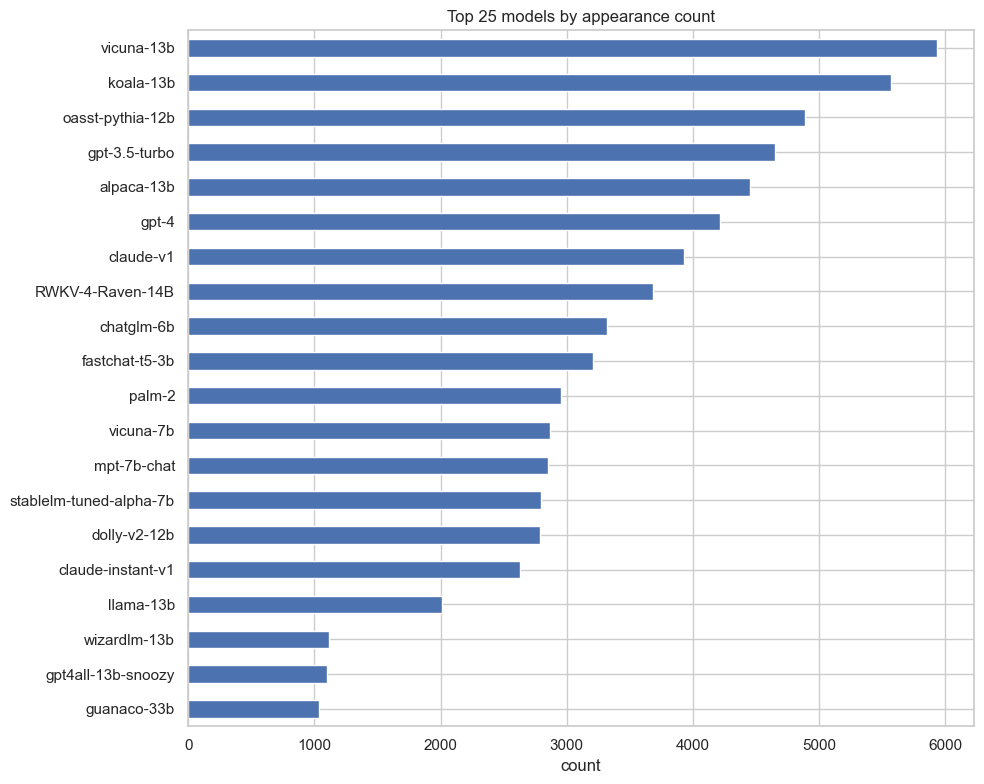

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
model_counts.head(25).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 25 models by appearance count')
ax.set_xlabel('count')
plt.tight_layout()
plt.show()

## 4. Winner distribution

winner
model_a          11744
model_b          11550
tie (bothbad)     6263
tie               3443
Name: count, dtype: int64


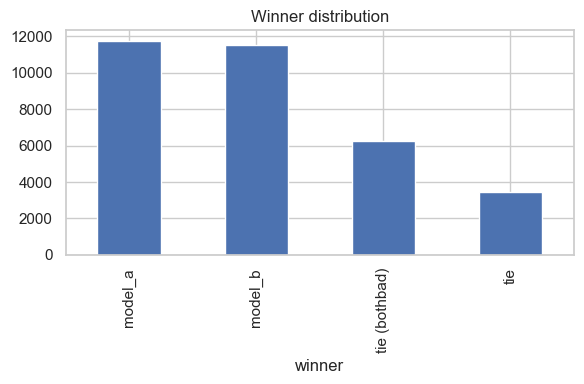

In [9]:
winner_counts = df['winner'].value_counts(dropna=False)
print(winner_counts)
winner_counts.plot(kind='bar', figsize=(6,4), title='Winner distribution')
plt.tight_layout(); plt.show()

In [10]:
# Win-rate per model (only model_a/model_b wins, ignore ties)
def win_rates(df):
    wins, plays = {}, {}
    for _, r in df.iterrows():
        for m in (r['model_a'], r['model_b']):
            plays[m] = plays.get(m, 0) + 1
        if r['winner'] == 'model_a':
            wins[r['model_a']] = wins.get(r['model_a'], 0) + 1
        elif r['winner'] == 'model_b':
            wins[r['model_b']] = wins.get(r['model_b'], 0) + 1
    out = pd.DataFrame({'plays': plays, 'wins': wins}).fillna(0)
    out['win_rate'] = (out['wins'] / out['plays']).round(3)
    return out.sort_values('win_rate', ascending=False)

wr = win_rates(df)
wr.head(20)

,plays,wins,win_rate
gpt-4,4217,2888,0.685
claude-v1,3927,2390,0.609
claude-instant-v1,2626,1493,0.569
gpt-3.5-turbo,4654,2524,0.542
vicuna-13b,5931,2667,0.450
guanaco-33b,1034,436,0.422
wizardlm-13b,1116,426,0.382
palm-2,2955,1125,0.381
koala-13b,5573,1901,0.341
vicuna-7b,2869,883,0.308


## 5. Languages

In [11]:
lang_counts = df['language'].value_counts()
print(f'Unique langs: {lang_counts.size}')
lang_counts.head(15)

Unique langs: 96


language
English       29206
German          676
Spanish         576
French          446
Portuguese      299
Russian         262
unknown         234
Chinese         135
Italian         134
Dutch            91
Japanese         88
Polish           87
Korean           50
Finnish          49
Danish           48
Name: count, dtype: int64

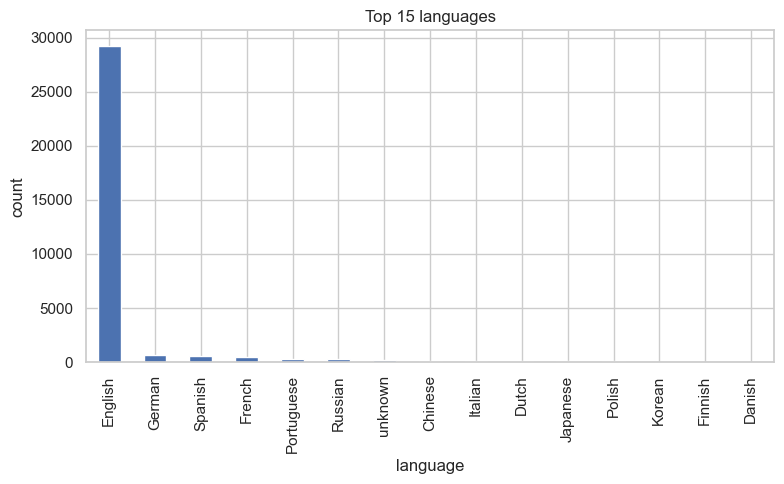

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
lang_counts.head(15).plot(kind='bar', ax=ax)
ax.set_title('Top 15 languages')
ax.set_ylabel('count')
plt.tight_layout(); plt.show()

## 6. Turns distribution

count    33000.000000
mean         1.191394
std          0.685822
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: turn, dtype: float64


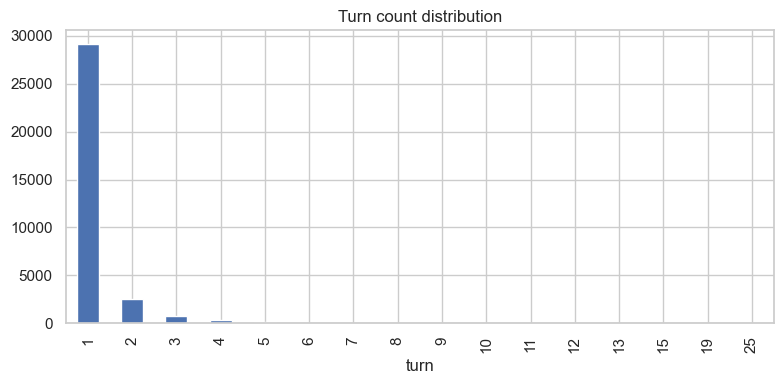

In [13]:
print(df['turn'].describe())
df['turn'].value_counts().sort_index().plot(kind='bar', figsize=(8,4), title='Turn count distribution')
plt.tight_layout(); plt.show()

## 7. Timestamps

Range: 2023-04-24 15:53:11.132200003 -> 2023-06-26 10:36:27.963799953


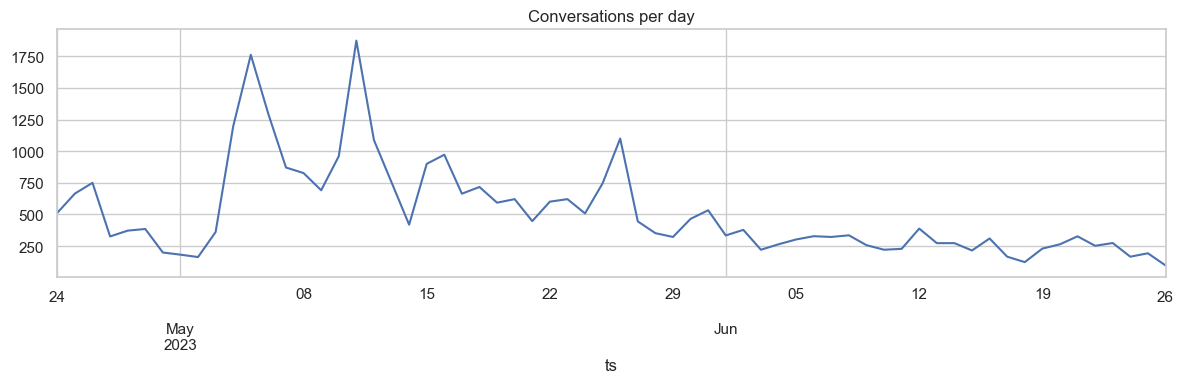

In [14]:
df['ts'] = pd.to_datetime(df['tstamp'], unit='s', errors='coerce')
print(f"Range: {df['ts'].min()} -> {df['ts'].max()}")
df.set_index('ts').resample('1D').size().plot(figsize=(12,4), title='Conversations per day')
plt.tight_layout(); plt.show()

## 8. Anonymous flag

In [15]:
df['anony'].value_counts(dropna=False)

anony
True    33000
Name: count, dtype: int64

## 9. Conversation structure

`conversation_a` / `conversation_b` stored as stringified list of `{role, content}` dicts.

In [16]:
def parse_conv(s):
    if not isinstance(s, str):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        try:
            return json.loads(s)
        except Exception:
            return []

sample = df.sample(min(2000, len(df)), random_state=42).copy()
sample['conv_a_parsed'] = sample['conversation_a'].map(parse_conv)
sample['conv_b_parsed'] = sample['conversation_b'].map(parse_conv)
sample['msgs_a'] = sample['conv_a_parsed'].map(len)
sample['msgs_b'] = sample['conv_b_parsed'].map(len)
sample[['msgs_a','msgs_b']].describe()

,msgs_a,msgs_b
count,2000.0,2000.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


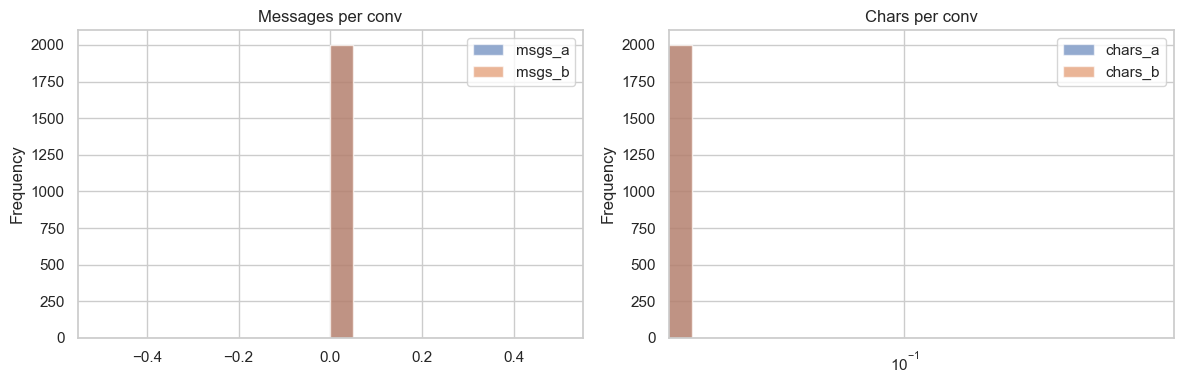

In [17]:
def total_chars(conv):
    return sum(len(m.get('content','')) for m in conv if isinstance(m, dict))

sample['chars_a'] = sample['conv_a_parsed'].map(total_chars)
sample['chars_b'] = sample['conv_b_parsed'].map(total_chars)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sample[['msgs_a','msgs_b']].plot(kind='hist', bins=20, alpha=0.6, ax=axes[0], title='Messages per conv')
sample[['chars_a','chars_b']].plot(kind='hist', bins=40, alpha=0.6, ax=axes[1], title='Chars per conv', logx=True)
plt.tight_layout(); plt.show()

In [18]:
# Example conversation
row = sample.iloc[0]
print(f"model_a: {row['model_a']}  |  model_b: {row['model_b']}  |  winner: {row['winner']}")
print('--- conversation_a ---')
for m in row['conv_a_parsed'][:6]:
    print(f"[{m.get('role')}] {m.get('content','')[:300]}")
print('--- conversation_b ---')
for m in row['conv_b_parsed'][:6]:
    print(f"[{m.get('role')}] {m.get('content','')[:300]}")

model_a: oasst-pythia-12b  |  model_b: gpt-3.5-turbo  |  winner: model_b
--- conversation_a ---
--- conversation_b ---


## 10. Moderation & toxicity flags

In [19]:
print('toxic_chat_tag value_counts:')
print(df['toxic_chat_tag'].value_counts(dropna=False).head(10))
print('\nopenai_moderation non-null:', df['openai_moderation'].notna().sum())
print('\nsample moderation entry:')
print(str(df['openai_moderation'].dropna().iloc[0])[:600])

toxic_chat_tag value_counts:
toxic_chat_tag
{'roberta-large': {'flagged': False, 'probability': 0.01309784036129713}, 't5-large': {'flagged': False, 'score': 0.000596902057064308}}       65
{'roberta-large': {'flagged': False, 'probability': 0.01259829942137003}, 't5-large': {'flagged': False, 'score': 0.00033144452842459593}}     61
{'roberta-large': {'flagged': False, 'probability': 0.03586466610431671}, 't5-large': {'flagged': False, 'score': 0.0003738000208803882}}      48
{'roberta-large': {'flagged': False, 'probability': 0.011138235218822956}, 't5-large': {'flagged': False, 'score': 0.00026607797168654024}}    34
{'roberta-large': {'flagged': False, 'probability': 0.02479308657348156}, 't5-large': {'flagged': False, 'score': 0.0005649927139508293}}      34
{'roberta-large': {'flagged': False, 'probability': 0.0915207639336586}, 't5-large': {'flagged': False, 'score': 0.337391602246495}}           33
{'roberta-large': {'flagged': False, 'probability': 0.014710931107401848}, 't5-l

## 11. Judges

In [20]:
j = df['judge'].value_counts()
print(f'Unique judges: {j.size}')
print(j.head(10))
print(f'\nConversations per judge — mean: {j.mean():.2f}, median: {j.median()}, max: {j.max()}')

Unique judges: 13383
judge
arena_user_9965     380
arena_user_257      292
arena_user_15085    288
arena_user_13046    265
arena_user_11473    201
arena_user_3820     197
arena_user_6467     131
arena_user_9676     122
arena_user_6585     107
arena_user_1338     106
Name: count, dtype: int64

Conversations per judge — mean: 2.47, median: 1.0, max: 380


## 12. Summary

- Rows / cols, missing %, dup question_ids — above.
- Top models + matchup volume.
- Winner split (incl. ties).
- Lang skew → likely EN-dominant.
- Turn dist + multi-turn share.
- Time range of collection.
- Conv length stats (msgs + chars).
- Moderation/toxicity flag coverage.
- Judge concentration.